У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

In [32]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.combine import SMOTETomek

import matplotlib.pyplot as plt

In [33]:
customer_df = pd.read_csv("customer_segmentation_train.csv")

customer_df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [34]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [35]:
numeric_features = [
    "Age",
    "Work_Experience",
    "Family_Size"
]

categorical_features = [
    "Gender",
    "Ever_Married",
    "Graduated",
    "Profession",
    "Spending_Score",
    "Var_1"
]

In [36]:
X = customer_df.drop("Segmentation", axis=1)
y = customer_df["Segmentation"]

In [37]:
X = X.drop("ID", axis=1)

In [38]:
input_train, input_test, target_train, target_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Розмір train:", input_train.shape)
print("Розмір test:", input_test.shape)

Розмір train: (6454, 9)
Розмір test: (1614, 9)


In [39]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [16]:
!pip install imbalanced-learn

In [41]:
print("Розподіл класів у train:")
print(target_train.value_counts())

Розподіл класів у train:
Segmentation
D    1814
A    1578
C    1576
B    1486
Name: count, dtype: int64


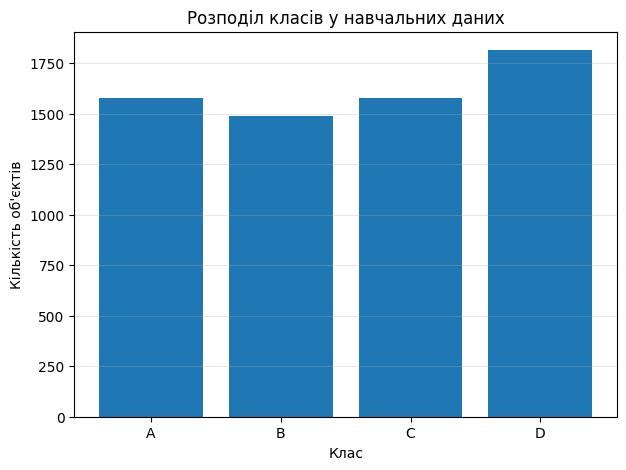

In [57]:
class_counts = target_train.value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Клас")
plt.ylabel("Кількість об'єктів")
plt.title("Розподіл класів у навчальних даних")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [42]:
cat_feature_indices = [
    input_train.columns.get_loc(col)
    for col in categorical_features
]

print("Індекси категоріальних ознак:", cat_feature_indices)

Індекси категоріальних ознак: [0, 1, 3, 4, 6, 8]


In [44]:
preprocessor_smotenc = ColumnTransformer(
    transformers=[(
            "num",
            SimpleImputer(strategy="median"),
            numeric_features),
        (
            "cat",
            SimpleImputer(strategy="most_frequent"),
            categorical_features)
    ]
)

In [45]:
pipeline_smotenc = ImbPipeline(steps=[
    ("preprocessor", preprocessor_smotenc),

    ("smotenc", SMOTENC(
        categorical_features=[3, 4, 5, 6, 7, 8],
        random_state=42
    )),

    ("postprocessor", ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                [0, 1, 2]
            ),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                [3, 4, 5, 6, 7, 8]
            )
        ]
    )),

    ("classifier", OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    ))
])

In [46]:
pipeline_smote_tomek = ImbPipeline(steps=[
    ("preprocessor", preprocessor),

    ("smote_tomek", SMOTETomek(
        random_state=42
    )),

    ("classifier", OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    ))
])

**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

In [47]:
pipeline_original = ImbPipeline(steps=[
    ("preprocessor", preprocessor),

    ("classifier", OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    ))
])

In [48]:
pipeline_original.fit(
    input_train,
    target_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Work_Experience',
                                                   'Family_Size']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Ever_Married',
                                                   'Graduated', 'Profession',
                                                   'Spending_Score',
                                                   'Var_1'])])),
                ('classifier',
                 OneVsRestClassifier(estimator=LogisticRegression(max_iter=2000,
                                                                  random_state=42)))])

In [49]:
pred_original = pipeline_original.predict(input_test)

In [50]:
pipeline_smotenc.fit(
    input_train,
    target_train
)

pred_smotenc = pipeline_smotenc.predict(
    input_test
)

In [51]:
pipeline_smote_tomek.fit(
    input_train,
    target_train
)

pred_smote_tomek = pipeline_smote_tomek.predict(
    input_test
)

In [52]:
print("=" * 60)
print("МОДЕЛЬ 1 — ОРИГІНАЛЬНІ ДАНІ")
print("=" * 60)

print(classification_report(
    target_test,
    pred_original
))


print("=" * 60)
print("МОДЕЛЬ 2 — SMOTENC")
print("=" * 60)

print(classification_report(
    target_test,
    pred_smotenc
))


print("=" * 60)
print("МОДЕЛЬ 3 — SMOTE-TOMEK")
print("=" * 60)

print(classification_report(
    target_test,
    pred_smote_tomek
))

МОДЕЛЬ 1 — ОРИГІНАЛЬНІ ДАНІ
              precision    recall  f1-score   support

           A       0.41      0.45      0.43       394
           B       0.40      0.17      0.24       372
           C       0.49      0.61      0.54       394
           D       0.64      0.76      0.70       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.48      1614
weighted avg       0.49      0.51      0.49      1614

МОДЕЛЬ 2 — SMOTENC
              precision    recall  f1-score   support

           A       0.42      0.47      0.44       394
           B       0.42      0.26      0.32       372
           C       0.52      0.59      0.55       394
           D       0.67      0.72      0.69       454

    accuracy                           0.52      1614
   macro avg       0.51      0.51      0.50      1614
weighted avg       0.51      0.52      0.51      1614

МОДЕЛЬ 3 — SMOTE-TOMEK
              precision    recall  f1-score   support

     

In [53]:
results = pd.DataFrame({
    "Model": [
        "Original",
        "SMOTENC",
        "SMOTE-Tomek"
    ],

    "Macro F1": [
        f1_score(
            target_test,
            pred_original,
            average="macro"
        ),

        f1_score(
            target_test,
            pred_smotenc,
            average="macro"
        ),

        f1_score(
            target_test,
            pred_smote_tomek,
            average="macro"
        )
    ],

    "Balanced Accuracy": [
        balanced_accuracy_score(
            target_test,
            pred_original
        ),

        balanced_accuracy_score(
            target_test,
            pred_smotenc
        ),

        balanced_accuracy_score(
            target_test,
            pred_smote_tomek
        )
    ]
})

results

,Model,Macro F1,Balanced Accuracy
0,Original,0.478404,0.497788
1,SMOTENC,0.503073,0.511239
2,SMOTE-Tomek,0.493246,0.502091


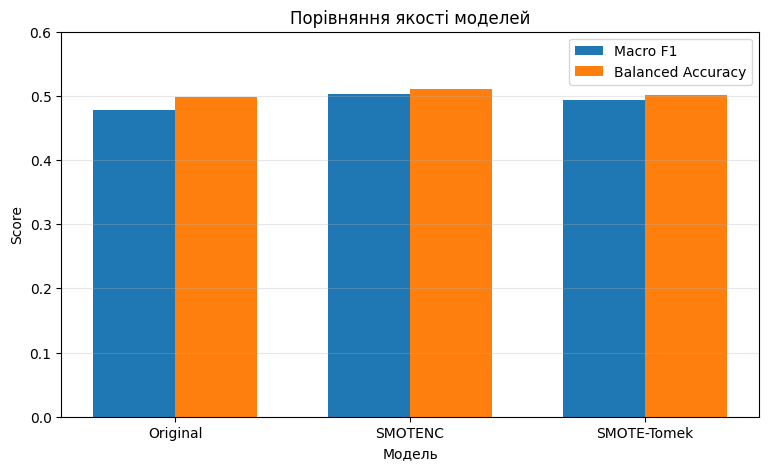

In [58]:
plt.figure(figsize=(9, 5))

x = np.arange(len(results["Model"]))
width = 0.35

plt.bar(
    x - width / 2,
    results["Macro F1"],
    width,
    label="Macro F1"
)

plt.bar(
    x + width / 2,
    results["Balanced Accuracy"],
    width,
    label="Balanced Accuracy"
)

plt.xticks(x, results["Model"])
plt.ylabel("Score")
plt.xlabel("Модель")
plt.title("Порівняння якості моделей")
plt.ylim(0, 0.6)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

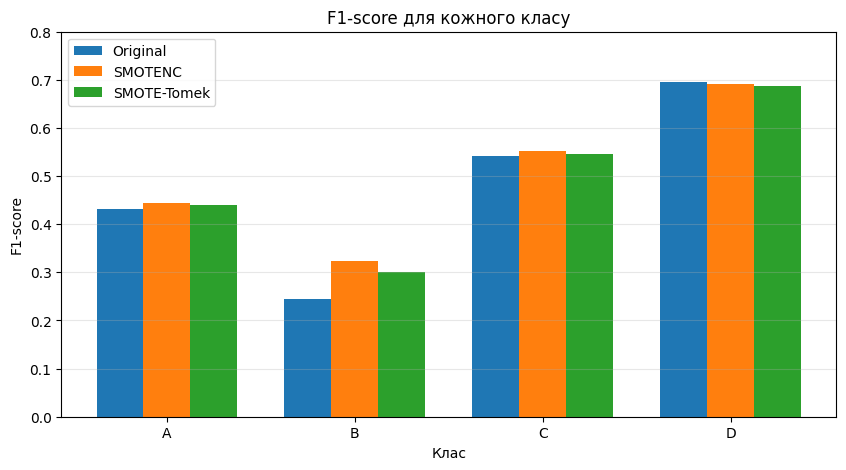

In [59]:
reports = {
    "Original": classification_report(
        target_test,
        pred_original,
        output_dict=True
    ),

    "SMOTENC": classification_report(
        target_test,
        pred_smotenc,
        output_dict=True
    ),

    "SMOTE-Tomek": classification_report(
        target_test,
        pred_smote_tomek,
        output_dict=True
    )
}

classes = ["A", "B", "C", "D"]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 5))

for i, (model_name, report) in enumerate(reports.items()):
    f1_values = [
        report[class_name]["f1-score"]
        for class_name in classes
    ]

    plt.bar(
        x + (i - 1) * width,
        f1_values,
        width,
        label=model_name
    )

plt.xticks(x, classes)
plt.xlabel("Клас")
plt.ylabel("F1-score")
plt.title("F1-score для кожного класу")
plt.ylim(0, 0.8)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

### Яку метрику обрано для порівняння моделей?

Для порівняння моделей обрано **Macro F1-score**. Ця метрика обчислює F1-score окремо для кожного класу та потім знаходить їх середнє значення. Вона є доцільною для багатокласової класифікації, оскільки однаково враховує якість класифікації всіх класів A, B, C та D.

Чим вище значення Macro F1-score, тим кращою є модель.


### Яка модель найкраща?

Найкращою є модель **SMOTENC**. Вона отримала найвище значення Macro F1-score — **0.5031**, тоді як модель на оригінальних даних отримала 0.4784, а модель SMOTE-Tomek — 0.4932.

Також SMOTENC має найвище значення Balanced Accuracy — **0.5112**. Отже, використання SMOTENC дозволило отримати найкращий результат серед трьох розглянутих моделей.


### Аналіз результатів

SMOTENC показав найкращий результат, оскільки він враховує як числові, так і категоріальні ознаки під час створення синтетичних об'єктів для менш представлених класів.

Порівняно з моделлю на оригінальних даних, Macro F1-score збільшився з **0.4784 до 0.5031**. SMOTE-Tomek також покращив результат до **0.4932**, але його показник залишився трохи нижчим за SMOTENC.

Отже, для цього датасету SMOTENC виявився найбільш ефективним методом балансування класів.